<h1><center>ASSIGNMENT</center></h1>

<h1><center>LINEAR & POLYNOMIAL REGRESSION MODELLING</center></h1>

<h1>Task1 : Data prepartion</h1>

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv(r"C:\Users\NEHA REDDY\Downloads\car_price_dataset.csv")

In [3]:
df.head()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price in $
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   wheelbase         205 non-null    float64
 3   carlength         205 non-null    float64
 4   carwidth          205 non-null    float64
 5   carheight         205 non-null    float64
 6   curbweight        205 non-null    int64  
 7   enginesize        205 non-null    int64  
 8   boreratio         205 non-null    float64
 9   stroke            205 non-null    float64
 10  compressionratio  205 non-null    float64
 11  horsepower        205 non-null    int64  
 12  peakrpm           205 non-null    int64  
 13  citympg           205 non-null    int64  
 14  highwaympg        205 non-null    int64  
 15  price in $        205 non-null    float64
dtypes: float64(8), int64(8)
memory usage: 25.8 K

In [6]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price in $
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.709756
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.851862
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [8]:
df.isnull().sum()

car_ID              0
symboling           0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginesize          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price in $          0
dtype: int64

In [9]:
# Remove unnecessary column
df=df.drop("car_ID",axis=1)

In [19]:
# Separate features and target
x = df.drop("price in $", axis=1)
y = df["price in $"]
print("Feature Shapes:" ,x.shape)
print("Target shape:" , y.shape)

Feature Shapes: (205, 14)
Target shape: (205,)


<h1>Task 2: Data Analysis</h1>

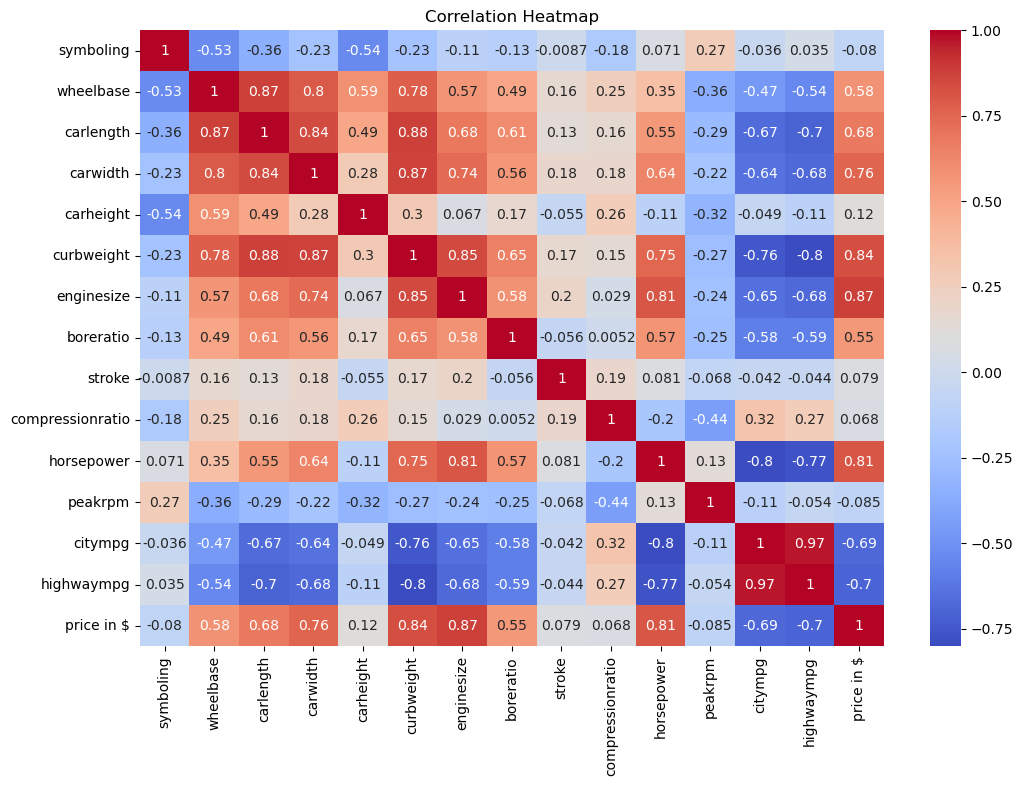

In [13]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

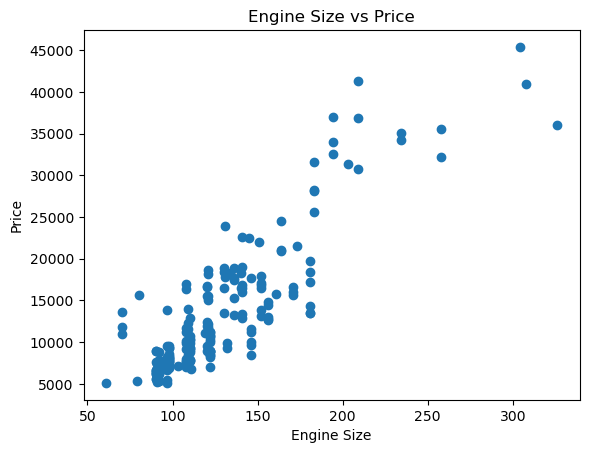

In [14]:
 #Scatter plot: Engine size vs Price
plt.scatter(df["enginesize"], df["price in $"])
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Engine Size vs Price")
plt.show()

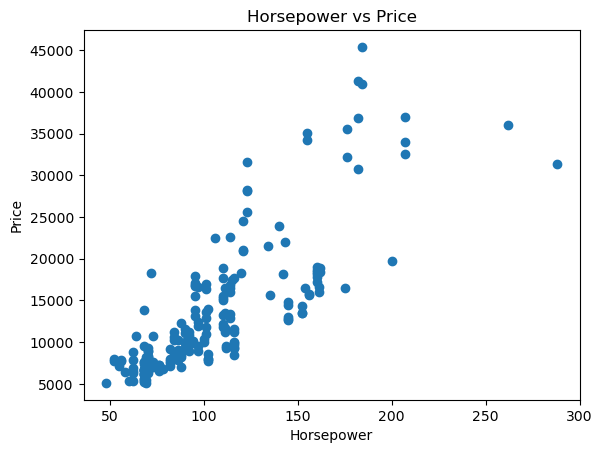

In [15]:
# Scatter plot: Horsepower vs Price
plt.scatter(df["horsepower"], df["price in $"])
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Horsepower vs Price")
plt.show()

<h1>Task 3: Train Test Split</h1>

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train , y_test = train_test_split(x,y,test_size=32,random_state=42)
print(x_train.shape , y_train.shape)

(173, 14) (173,)


<h1>Task 4: Linear Regression Model</h1>

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
# Train model
lin_model = LinearRegression()
lin_model.fit(x_train, y_train)

# Predictions
y_pred_train = lin_model.predict(x_train)
y_pred_test = lin_model.predict(x_test)

# Evaluation
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("Linear Regression Performance")
print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)
print("Train R2:", r2_train)
print("Test R2:", r2_test)

Linear Regression Performance
Train RMSE: 2882.9801571476955
Test RMSE: 4071.835873382362
Train R2: 0.8589435695435594
Test R2: 0.8120059685659204


<h1>Task 5: Polynomial Regression Model</h1> 

In [24]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Train regression model
poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

# Predictions
y_pred_train_poly = poly_model.predict(x_train_poly)
y_pred_test_poly = poly_model.predict(x_test_poly)

# Evaluation
rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_pred_train_poly))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_test_poly))

r2_train_poly = r2_score(y_train, y_pred_train_poly)
r2_test_poly = r2_score(y_test, y_pred_test_poly)

print("\nPolynomial Regression Performance")
print("Train RMSE:", rmse_train_poly)
print("Test RMSE:", rmse_test_poly)
print("Train R2:", r2_train_poly)
print("Test R2:", r2_test_poly)



Polynomial Regression Performance
Train RMSE: 777.6213717579411
Test RMSE: 13878.669915131946
Train R2: 0.9897376703994123
Test R2: -1.184033151798376


<h1>Task 6: Model Comparison</h1>

In [25]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "Train RMSE": [rmse_train, rmse_train_poly],
    "Test RMSE": [rmse_test, rmse_test_poly],
    "Train R2": [r2_train, r2_train_poly],
    "Test R2": [r2_test, r2_test_poly]
})

print(comparison)

                   Model   Train RMSE     Test RMSE  Train R2   Test R2
0      Linear Regression  2882.980157   4071.835873  0.858944  0.812006
1  Polynomial Regression   777.621372  13878.669915  0.989738 -1.184033
